# Sepsis early warning pipeline with demographic subgroup evaluation

This notebook is organized into:
1. Setup and helper functions
2. Data loading and preprocessing
3. Data overview / exploration
4. Full model training and overall evaluation
5. Gender × age subgroup performance
6. Saving outputs


In [1]:
# =========================
# Setup and imports
# =========================

from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False


# =========================
# Configuration
# =========================

SEED = 1
DATA_DIR = Path('./data/')
OUTPUT_DIR = Path('results_notebook')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 8
EPOCHS = 12
BATCH_SIZE = 128
LR = 1e-3
TEST_SIZE = 0.30
LIU_LIKE_WINDOW = (-2, -1)
TARGET_COL = 'SepsisLabel'
SEPSIS_LABEL_LEAD = 6

ALL_FEATURES = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
    'HospAdmTime', 'ICULOS'
]

print('DATA_DIR:', DATA_DIR.resolve() if DATA_DIR.exists() else DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
print('HAS_XGBOOST:', HAS_XGBOOST)
print('HAS_TORCH:', HAS_TORCH)

DATA_DIR: /Users/roseva1/Desktop/home/rose1838/SP26/PUBH8475/PUBH8475/Final/data
OUTPUT_DIR: /Users/roseva1/Desktop/home/rose1838/SP26/PUBH8475/PUBH8475/Final/results_notebook
HAS_XGBOOST: False
HAS_TORCH: True


In [2]:
# =========================
# Helper classes and functions
# =========================

@dataclass
class PatientSummary:
    patient_id: str
    n_rows: int
    onset_idx: Optional[int]
    became_septic: bool


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    if HAS_TORCH:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


def find_patient_files(data_dir: Path, recursive: bool = True) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f'DATA_DIR does not exist: {data_dir}')

    pattern_func = data_dir.rglob if recursive else data_dir.glob
    files = list(pattern_func('*.psv')) + list(pattern_func('*.csv'))
    files = sorted(f for f in files if f.is_file() and f.stem.startswith('p'))

    if not files:
        raise FileNotFoundError(f'No patient .psv or .csv files found under {data_dir}')

    print(f'Found {len(files)} patient files.')
    print('First few files:')
    for f in files[:5]:
        print(' -', f)
    return files


def load_patient_file(fp: Path) -> pd.DataFrame:
    if fp.suffix.lower() == '.psv':
        df = pd.read_csv(fp, sep='|')
    elif fp.suffix.lower() == '.csv':
        df = pd.read_csv(fp)
    else:
        raise ValueError(f'Unsupported file type: {fp}')

    if TARGET_COL not in df.columns:
        raise ValueError(f"{fp} is missing required target column '{TARGET_COL}'")

    missing_features = [c for c in ALL_FEATURES if c not in df.columns]
    for c in missing_features:
        df[c] = np.nan

    df = df[ALL_FEATURES + [TARGET_COL]].copy()
    df['patient_id'] = fp.stem
    df['t'] = np.arange(len(df), dtype=int)
    return df


def load_all_patients(data_dir: Path) -> Tuple[pd.DataFrame, List[PatientSummary]]:
    files = find_patient_files(data_dir, recursive=True)
    frames = []
    summaries = []

    for fp in tqdm(files, desc='Loading patient files'):
        df = load_patient_file(fp)
        onset_positions = np.where(df[TARGET_COL].fillna(0).values.astype(int) == 1)[0]
        onset_idx = int(onset_positions[0]) if len(onset_positions) > 0 else None
        became_septic = onset_idx is not None
        summaries.append(PatientSummary(fp.stem, len(df), onset_idx, became_septic))
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    return full, summaries


def split_patients(summaries: List[PatientSummary], test_size: float = 0.30, seed: int = 42) -> Tuple[List[str], List[str]]:
    patient_ids = [s.patient_id for s in summaries]
    labels = [int(s.became_septic) for s in summaries]
    train_ids, test_ids = train_test_split(
        patient_ids,
        test_size=test_size,
        random_state=seed,
        stratify=labels if len(set(labels)) > 1 else None
    )
    return sorted(train_ids), sorted(test_ids)


def add_missingness_and_deltas(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    out = df.copy()

    for c in tqdm(feature_cols, desc='Adding missingness flags'):
        out[f'{c}_missing'] = out[c].isna().astype(int)

    out = out.sort_values(['patient_id', 't']).copy()
    grouped = []
    for _, g in tqdm(out.groupby('patient_id'), desc='Computing deltas', total=out['patient_id'].nunique()):
        g = g.copy()
        ff = g[feature_cols].ffill()
        deltas = ff.diff().fillna(0.0)
        deltas.columns = [f'{c}_delta' for c in feature_cols]
        grouped.append(pd.concat([g, deltas], axis=1))

    return pd.concat(grouped, ignore_index=True)


def get_label_start_and_estimated_onset(g: pd.DataFrame, target_col: str = TARGET_COL, label_lead: int = 6):
    g = g.sort_values('t').reset_index(drop=True).copy()
    pos = np.where(g[target_col].fillna(0).values.astype(int) == 1)[0]
    if len(pos) == 0:
        return None, None
    label_start_t = int(g.iloc[pos[0]]['t'])
    estimated_onset_t = label_start_t + label_lead
    return label_start_t, estimated_onset_t


def build_proxy_training_rows(df: pd.DataFrame, patient_ids: List[str], event_window: Tuple[int, int] = (-2, -1), label_lead: int = 6) -> pd.DataFrame:
    lo, hi = event_window
    sub = df[df['patient_id'].isin(patient_ids)].copy()
    out_frames = []

    for pid, g in tqdm(sub.groupby('patient_id'), desc='Building proxy rows', total=sub['patient_id'].nunique()):
        g = g.sort_values('t').reset_index(drop=True).copy()
        label_start_t, event_t = get_label_start_and_estimated_onset(g, TARGET_COL, label_lead=label_lead)

        if event_t is None:
            gg = g.copy()
            gg['proxy_label'] = 0
            out_frames.append(gg)
            continue

        start = event_t + lo
        end = event_t + hi
        mask = (g['t'] >= start) & (g['t'] <= end)
        gg = g.loc[mask].copy()
        if len(gg) == 0:
            continue
        gg['proxy_label'] = 1
        out_frames.append(gg)

    if not out_frames:
        raise RuntimeError('No proxy rows generated.')
    return pd.concat(out_frames, ignore_index=True)


def choose_feature_columns(df: pd.DataFrame) -> List[str]:
    base = [c for c in ALL_FEATURES if c in df.columns]
    missing = [c for c in df.columns if c.endswith('_missing')]
    delta = [c for c in df.columns if c.endswith('_delta')]
    return base + missing + delta


def train_glm(X_train: pd.DataFrame, y_train: np.ndarray) -> Pipeline:
    model = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver='liblinear',
            penalty='l1',
            max_iter=2000,
            class_weight='balanced',
            random_state=SEED
        ))
    ])
    model.fit(X_train, y_train)
    return model


def train_xgboost(X_train: pd.DataFrame, y_train: np.ndarray):
    if not HAS_XGBOOST:
        raise ImportError('xgboost is not installed.')
    pos = max(1, int(np.sum(y_train == 1)))
    neg = max(1, int(np.sum(y_train == 0)))
    scale_pos_weight = neg / pos

    model = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='auc',
            random_state=SEED,
            scale_pos_weight=scale_pos_weight,
            n_jobs=4
        ))
    ])
    model.fit(X_train, y_train)
    return model


class SequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


class GRUClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        h = out[:, -1, :]
        return self.fc(h).squeeze(-1)


def build_patient_sequences(df: pd.DataFrame, patient_ids: List[str], feature_cols: List[str], seq_len: int = 8, event_window: Tuple[int, int] = (-2, -1), label_lead: int = 6) -> Tuple[np.ndarray, np.ndarray]:
    sub = df[df['patient_id'].isin(patient_ids)].copy()
    sequences = []
    labels = []

    for pid, g in tqdm(sub.groupby('patient_id'), desc='Building sequences', total=sub['patient_id'].nunique()):
        g = g.sort_values('t').reset_index(drop=True).copy()
        label_start_t, event_t = get_label_start_and_estimated_onset(g, TARGET_COL, label_lead=label_lead)

        if event_t is None:
            for end_t in range(seq_len - 1, len(g)):
                block = g.iloc[end_t - seq_len + 1:end_t + 1]
                sequences.append(block[feature_cols].values)
                labels.append(0)
            continue

        start = event_t + event_window[0]
        end = event_t + event_window[1]
        for end_idx in range(len(g)):
            current_t = int(g.iloc[end_idx]['t'])
            if current_t < max(seq_len - 1, start) or current_t > end:
                continue
            block = g.iloc[end_idx - seq_len + 1:end_idx + 1]
            if len(block) == seq_len:
                sequences.append(block[feature_cols].values)
                labels.append(1)

    if not sequences:
        raise RuntimeError('No sequences created.')
    return np.stack(sequences), np.array(labels, dtype=int)


def median_impute_and_scale_for_rnn(train_seq: np.ndarray, test_seq: np.ndarray):
    n_train, seq_len, n_feat = train_seq.shape
    n_test = test_seq.shape[0]
    tr2 = train_seq.reshape(-1, n_feat)
    te2 = test_seq.reshape(-1, n_feat)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    tr2 = scaler.fit_transform(imputer.fit_transform(tr2))
    te2 = scaler.transform(imputer.transform(te2))
    return tr2.reshape(n_train, seq_len, n_feat), te2.reshape(n_test, seq_len, n_feat), imputer, scaler


def train_rnn(X_train, y_train, X_val, y_val, epochs=12, batch_size=128, lr=1e-3):
    if not HAS_TORCH:
        raise ImportError('torch is not installed.')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_ds = SequenceDataset(X_train, y_train)
    val_ds = SequenceDataset(X_val, y_val)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    model = GRUClassifier(input_size=X_train.shape[-1], hidden_size=64, num_layers=1).to(device)

    cls_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train.astype(int))
    pos_weight = torch.tensor([cls_weights[1] / cls_weights[0]], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_auc = -np.inf

    for epoch in tqdm(range(epochs), desc='Training GRU'):
        model.train()
        train_losses = []
        for xb, yb in tqdm(train_dl, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_probs = []
        val_true = []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(device)
                logits = model(xb)
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs.tolist())
                val_true.extend(yb.numpy().tolist())

        val_auc = roc_auc_score(val_true, val_probs) if len(set(val_true)) > 1 else np.nan
        print(f'Epoch {epoch+1}: train_loss={np.mean(train_losses):.4f}, val_auc={val_auc:.4f}')
        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def predict_rnn(model, X: np.ndarray) -> np.ndarray:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    model.to(device)
    ds = SequenceDataset(X, np.zeros(len(X)))
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    probs = []
    for xb, _ in tqdm(dl, desc='Predicting RNN probabilities'):
        xb = xb.to(device)
        with torch.no_grad():
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy()
        probs.extend(p.tolist())
    return np.array(probs)


def optimal_threshold_from_roc(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    dist = np.sqrt((1 - tpr) ** 2 + (fpr) ** 2)
    idx = int(np.argmin(dist))
    return {'threshold': float(thr[idx]), 'tpr': float(tpr[idx]), 'fpr': float(fpr[idx])}


def evaluate_static_model(model, X_test: pd.DataFrame, y_test: np.ndarray, model_name: str) -> Dict[str, float]:
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    thr_info = optimal_threshold_from_roc(y_test, probs)
    preds = (probs >= thr_info['threshold']).astype(int)
    acc = accuracy_score(y_test, preds)
    metrics = {
        'auc': float(auc),
        'accuracy_at_optimal_threshold': float(acc),
        'optimal_threshold': float(thr_info['threshold']),
        'sensitivity_at_optimal_threshold': float(thr_info['tpr']),
        'specificity_at_optimal_threshold': float(1.0 - thr_info['fpr']),
    }
    print(f'\n[{model_name}]')
    print(json.dumps(metrics, indent=2))
    return metrics


def build_full_patient_time_scores_static(model, df, patient_ids, feature_cols):
    sub = df[df['patient_id'].isin(patient_ids)].copy().sort_values(['patient_id', 't'])
    sub['risk_score'] = model.predict_proba(sub[feature_cols])[:, 1]
    return sub


def build_full_patient_time_scores_rnn(model, df, patient_ids, feature_cols, imputer, scaler, seq_len=8):
    sub = df[df['patient_id'].isin(patient_ids)].copy().sort_values(['patient_id', 't'])
    rows = []
    for pid, g in tqdm(sub.groupby('patient_id'), desc='Building RNN scoring windows', total=sub['patient_id'].nunique()):
        g = g.sort_values('t').copy().reset_index(drop=True)
        if len(g) < seq_len:
            continue
        for end_t in range(seq_len - 1, len(g)):
            block = g.iloc[end_t - seq_len + 1:end_t + 1]
            rows.append({'patient_id': pid, 't': int(g.loc[end_t, 't']), TARGET_COL: int(g.loc[end_t, TARGET_COL]), 'seq': block[feature_cols].values})

    if not rows:
        return pd.DataFrame(columns=['patient_id', 't', TARGET_COL, 'risk_score'])

    eval_df = pd.DataFrame(rows)
    X = np.stack(eval_df['seq'].values)
    n, seq_len, n_feat = X.shape
    X2 = X.reshape(-1, n_feat)
    X2 = imputer.transform(X2)
    X2 = scaler.transform(X2)
    X = X2.reshape(n, seq_len, n_feat)
    eval_df['risk_score'] = predict_rnn(model, X)
    return eval_df[['patient_id', 't', TARGET_COL, 'risk_score']]


def compute_early_warning_metrics(score_df: pd.DataFrame, threshold: float, label_lead: int = 6) -> Dict[str, float]:
    ewt_list = []
    n_positive_patients = 0
    n_detected_positive_patients = 0
    false_alert_patients = 0
    n_negative_patients = 0

    for pid, g in score_df.groupby('patient_id'):
        g = g.sort_values('t').reset_index(drop=True).copy()
        pos = np.where(g[TARGET_COL].fillna(0).values.astype(int) == 1)[0]
        detected_times = g.loc[g['risk_score'] >= threshold, 't'].tolist()

        if len(pos) > 0:
            n_positive_patients += 1
            label_start_t = int(g.iloc[pos[0]]['t'])
            event_t = label_start_t + label_lead
            valid_detections = [t for t in detected_times if t < event_t]
            if valid_detections:
                det_t = int(valid_detections[0])
                ewt_list.append(event_t - det_t)
                n_detected_positive_patients += 1
        else:
            n_negative_patients += 1
            if len(detected_times) > 0:
                false_alert_patients += 1

    return {
        'n_positive_patients': int(n_positive_patients),
        'n_detected_positive_patients': int(n_detected_positive_patients),
        'patient_sensitivity': float(n_detected_positive_patients / n_positive_patients) if n_positive_patients else np.nan,
        'n_negative_patients': int(n_negative_patients),
        'false_alert_patient_rate': float(false_alert_patients / n_negative_patients) if n_negative_patients else np.nan,
        'median_early_warning_time_hours': float(np.median(ewt_list)) if ewt_list else np.nan,
        'mean_early_warning_time_hours': float(np.mean(ewt_list)) if ewt_list else np.nan,
    }

## Data loading and preprocessing

In [3]:
# =========================
# Load data and build train/test sets
# =========================

paper_reference = {
    'GLM': {'AUC': 0.87, 'Sensitivity': 0.82, 'Specificity': 0.83, 'PPV': 0.49, 'Median_EWT': 6.9},
    'XGBoost': {'AUC': 0.85, 'Sensitivity': 0.76, 'Specificity': 0.79, 'PPV': 0.43, 'Median_EWT': 6.0},
    'RNN': {'AUC': 0.93, 'Sensitivity': 0.88, 'Specificity': 0.84, 'PPV': 0.52, 'Median_EWT': 7.0},
}

set_global_seed(SEED)

files = find_patient_files(DATA_DIR, recursive=True)
print('Ready to load:', len(files), 'files')

df, summaries = load_all_patients(DATA_DIR)
summary_preview = pd.DataFrame([s.__dict__ for s in summaries])

train_ids, test_ids = split_patients(summaries, test_size=TEST_SIZE, seed=SEED)
df_feat = add_missingness_and_deltas(df, ALL_FEATURES)
feature_cols = choose_feature_columns(df_feat)

train_rows = build_proxy_training_rows(df_feat, train_ids, event_window=LIU_LIKE_WINDOW, label_lead=SEPSIS_LABEL_LEAD)
test_rows = build_proxy_training_rows(df_feat, test_ids, event_window=LIU_LIKE_WINDOW, label_lead=SEPSIS_LABEL_LEAD)

X_train = train_rows[feature_cols]
y_train = train_rows['proxy_label'].astype(int).values
X_test = test_rows[feature_cols]
y_test = test_rows['proxy_label'].astype(int).values

print(f'Loaded {len(summaries)} patients')
print(f'Loaded {len(df):,} hourly rows')
print('Train patients:', len(train_ids))
print('Test patients:', len(test_ids))
print('Number of modeling features:', len(feature_cols))
print('First 10 features:', feature_cols[:10])
print('Train shape:', X_train.shape, '| positives:', int(y_train.sum()), '| negatives:', int((y_train == 0).sum()))
print('Test shape:', X_test.shape, '| positives:', int(y_test.sum()), '| negatives:', int((y_test == 0).sum()))

Found 40336 patient files.
First few files:
 - data/training_setA/training/p000001.psv
 - data/training_setA/training/p000002.psv
 - data/training_setA/training/p000003.psv
 - data/training_setA/training/p000004.psv
 - data/training_setA/training/p000005.psv
Ready to load: 40336 files
Found 40336 patient files.
First few files:
 - data/training_setA/training/p000001.psv
 - data/training_setA/training/p000002.psv
 - data/training_setA/training/p000003.psv
 - data/training_setA/training/p000004.psv
 - data/training_setA/training/p000005.psv


Loading patient files:   0%|          | 0/40336 [00:00<?, ?it/s]

Adding missingness flags:   0%|          | 0/40 [00:00<?, ?it/s]

Computing deltas:   0%|          | 0/40336 [00:00<?, ?it/s]

Building proxy rows:   0%|          | 0/28235 [00:00<?, ?it/s]

Building proxy rows:   0%|          | 0/12101 [00:00<?, ?it/s]

Loaded 40336 patients
Loaded 1,552,210 hourly rows
Train patients: 28235
Test patients: 12101
Number of modeling features: 120
First 10 features: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3']
Train shape: (969736, 120) | positives: 4090 | negatives: 965646
Test shape: (415908, 120) | positives: 1754 | negatives: 414154


## Data overview / exploration

In [4]:
# =========================
# Patient-level demographics and overview
# =========================

display(summary_preview.head())

gender_map = {0: 'Female', 1: 'Male'}

patient_demo = (
    df.sort_values(['patient_id', 't'])
      .groupby('patient_id', as_index=False)
      .first()[['patient_id', 'Age', 'Gender', TARGET_COL]]
      .copy()
)

patient_demo = patient_demo.merge(
    pd.DataFrame([s.__dict__ for s in summaries])[['patient_id', 'became_septic']],
    on='patient_id',
    how='left'
)

patient_demo['Gender_label'] = patient_demo['Gender'].map(gender_map).fillna('Missing/Other')

print('Patient-level demographic preview:')
display(patient_demo.head())

gender_counts_patients = (
    patient_demo['Gender_label']
    .value_counts(dropna=False)
    .rename_axis('Gender')
    .reset_index(name='n_patients')
)
gender_counts_patients['pct_patients'] = 100 * gender_counts_patients['n_patients'] / gender_counts_patients['n_patients'].sum()

print('Overall patient-level gender distribution:')
display(gender_counts_patients)

age_summary_by_gender = (
    patient_demo.groupby('Gender_label')['Age']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
print('Age summary by recorded gender:')
display(age_summary_by_gender)

,patient_id,n_rows,onset_idx,became_septic
0,p000001,54,NaN,False
1,p000002,23,NaN,False
2,p000003,48,NaN,False
3,p000004,29,NaN,False
4,p000005,48,NaN,False


Patient-level demographic preview:


,patient_id,Age,Gender,SepsisLabel,became_septic,Gender_label
0,p000001,83.14,0,0,False,Female
1,p000002,75.91,0,0,False,Female
2,p000003,45.82,0,0,False,Female
3,p000004,65.71,0,0,False,Female
4,p000005,28.09,1,0,False,Male


Overall patient-level gender distribution:


,Gender,n_patients,pct_patients
0,Male,22566,55.945061
1,Female,17770,44.054939


Age summary by recorded gender:


,Gender_label,count,mean,median,std,min,max
0,Female,17770,62.136710,64.000,17.310407,14.0,100.0
1,Male,22566,61.254976,62.875,15.790426,14.0,100.0


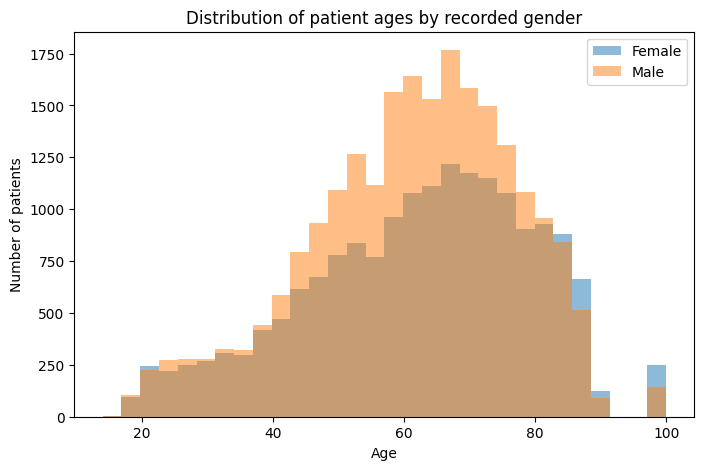

In [5]:
# =========================
# Histogram of age by gender
# =========================

plt.figure(figsize=(8, 5))
for gender in ['Female', 'Male', 'Missing/Other']:
    sub = patient_demo.loc[patient_demo['Gender_label'] == gender, 'Age'].dropna()
    if len(sub) > 0:
        plt.hist(sub, bins=30, alpha=0.5, label=gender)

plt.title('Distribution of patient ages by recorded gender')
plt.xlabel('Age')
plt.ylabel('Number of patients')
plt.legend()
plt.show()

## Train models and compute overall performance

In [6]:
# =========================
# Train GLM / XGBoost / GRU
# =========================

# GLM
glm = train_glm(X_train, y_train)
glm_metrics = evaluate_static_model(glm, X_test, y_test, 'GLM_L1')
joblib.dump(glm, OUTPUT_DIR / 'glm_l1.joblib')

# XGBoost
if HAS_XGBOOST:
    xgb = train_xgboost(X_train, y_train)
    xgb_metrics = evaluate_static_model(xgb, X_test, y_test, 'XGBoost')
    joblib.dump(xgb, OUTPUT_DIR / 'xgboost.joblib')
else:
    xgb = None
    xgb_metrics = None
    print('xgboost not installed')

# GRU
if HAS_TORCH:
    train_seq_X, train_seq_y = build_patient_sequences(
        df_feat, train_ids, feature_cols, seq_len=SEQ_LEN,
        event_window=LIU_LIKE_WINDOW, label_lead=SEPSIS_LABEL_LEAD
    )
    test_seq_X, test_seq_y = build_patient_sequences(
        df_feat, test_ids, feature_cols, seq_len=SEQ_LEN,
        event_window=LIU_LIKE_WINDOW, label_lead=SEPSIS_LABEL_LEAD
    )

    train_seq_X_scaled, test_seq_X_scaled, rnn_imputer, rnn_scaler = median_impute_and_scale_for_rnn(train_seq_X, test_seq_X)
    print('Train sequences:', train_seq_X_scaled.shape)
    print('Test sequences:', test_seq_X_scaled.shape)

    idx = np.arange(len(train_seq_X_scaled))
    tr_idx, val_idx = train_test_split(
        idx,
        test_size=0.15,
        random_state=SEED,
        stratify=train_seq_y if len(set(train_seq_y)) > 1 else None
    )

    rnn_model = train_rnn(
        train_seq_X_scaled[tr_idx], train_seq_y[tr_idx],
        train_seq_X_scaled[val_idx], train_seq_y[val_idx],
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR
    )

    torch.save(rnn_model.state_dict(), OUTPUT_DIR / 'gru_model.pt')
    rnn_probs = predict_rnn(rnn_model, test_seq_X_scaled)
    rnn_auc = roc_auc_score(test_seq_y, rnn_probs)
    rnn_thr = optimal_threshold_from_roc(test_seq_y, rnn_probs)
    rnn_preds = (rnn_probs >= rnn_thr['threshold']).astype(int)
    rnn_acc = accuracy_score(test_seq_y, rnn_preds)
    rnn_metrics = {
        'auc': float(rnn_auc),
        'accuracy_at_optimal_threshold': float(rnn_acc),
        'optimal_threshold': float(rnn_thr['threshold']),
        'sensitivity_at_optimal_threshold': float(rnn_thr['tpr']),
        'specificity_at_optimal_threshold': float(1.0 - rnn_thr['fpr']),
    }
    print('\n[RNN_GRU]')
    print(json.dumps(rnn_metrics, indent=2))
else:
    rnn_model = None
    rnn_imputer = None
    rnn_scaler = None
    rnn_metrics = None
    rnn_probs = None
    print('torch not installed')

/Users/roseva1/Desktop/home/rose1838/SP26/PUBH8475/VENV311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/roseva1/Desktop/home/rose1838/SP26/PUBH8475/VENV311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



[GLM_L1]
{
  "auc": 0.7872634455229306,
  "accuracy_at_optimal_threshold": 0.7606249459014974,
  "optimal_threshold": 0.48081935549965776,
  "sensitivity_at_optimal_threshold": 0.6887115165336374,
  "specificity_at_optimal_threshold": 0.7609295093129609
}
xgboost not installed


Building sequences:   0%|          | 0/28235 [00:00<?, ?it/s]

Building sequences:   0%|          | 0/12101 [00:00<?, ?it/s]

Train sequences: (785698, 8, 120)
Test sequences: (337047, 8, 120)


...

Epoch 11: train_loss=0.1531, val_auc=0.9479


Epoch 12/12:   0%|          | 0/5218 [00:00<?, ?it/s]

Epoch 12: train_loss=0.1556, val_auc=0.9506


Predicting RNN probabilities:   0%|          | 0/1317 [00:00<?, ?it/s]


[RNN_GRU]
{
  "auc": 0.8016125456180063,
  "accuracy_at_optimal_threshold": 0.7551142718967978,
  "optimal_threshold": 0.00537517573684454,
  "sensitivity_at_optimal_threshold": 0.7020833333333333,
  "specificity_at_optimal_threshold": 0.7553418134901835
}


In [7]:
# =========================
# Overall patient-time scores and metrics
# =========================

results = {}

glm_scores = build_full_patient_time_scores_static(glm, df_feat, test_ids, feature_cols)
glm_ewt = compute_early_warning_metrics(glm_scores, glm_metrics['optimal_threshold'])
results['glm_row'] = glm_metrics
results['glm_patient_time'] = glm_ewt
glm_scores.to_csv(OUTPUT_DIR / 'glm_test_time_scores.csv', index=False)

if HAS_XGBOOST and xgb is not None:
    xgb_scores = build_full_patient_time_scores_static(xgb, df_feat, test_ids, feature_cols)
    xgb_ewt = compute_early_warning_metrics(xgb_scores, xgb_metrics['optimal_threshold'])
    results['xgb_row'] = xgb_metrics
    results['xgb_patient_time'] = xgb_ewt
    xgb_scores.to_csv(OUTPUT_DIR / 'xgb_test_time_scores.csv', index=False)
else:
    xgb_scores = None

if HAS_TORCH and rnn_model is not None:
    rnn_scores = build_full_patient_time_scores_rnn(rnn_model, df_feat, test_ids, feature_cols, rnn_imputer, rnn_scaler, seq_len=SEQ_LEN)
    rnn_ewt = compute_early_warning_metrics(rnn_scores, rnn_metrics['optimal_threshold'])
    results['rnn_row'] = rnn_metrics
    results['rnn_patient_time'] = rnn_ewt
    rnn_scores.to_csv(OUTPUT_DIR / 'rnn_test_time_scores.csv', index=False)
else:
    rnn_scores = None

display(pd.DataFrame(results).T)

summary_rows = []
if 'glm_row' in results:
    summary_rows.append({'model': 'GLM_L1', 'AUC': results['glm_row']['auc'], 'Sensitivity': results['glm_row']['sensitivity_at_optimal_threshold'], 'Specificity': results['glm_row']['specificity_at_optimal_threshold'], 'Median Early Warning (hrs)': results['glm_patient_time']['median_early_warning_time_hours']})
if 'xgb_row' in results:
    summary_rows.append({'model': 'XGBoost', 'AUC': results['xgb_row']['auc'], 'Sensitivity': results['xgb_row']['sensitivity_at_optimal_threshold'], 'Specificity': results['xgb_row']['specificity_at_optimal_threshold'], 'Median Early Warning (hrs)': results['xgb_patient_time']['median_early_warning_time_hours']})
if 'rnn_row' in results:
    summary_rows.append({'model': 'GRU', 'AUC': results['rnn_row']['auc'], 'Sensitivity': results['rnn_row']['sensitivity_at_optimal_threshold'], 'Specificity': results['rnn_row']['specificity_at_optimal_threshold'], 'Median Early Warning (hrs)': results['rnn_patient_time']['median_early_warning_time_hours']})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

Building RNN scoring windows:   0%|          | 0/12101 [00:00<?, ?it/s]

Predicting RNN probabilities:   0%|          | 0/1492 [00:00<?, ?it/s]

,auc,accuracy_at_optimal_threshold,optimal_threshold,sensitivity_at_optimal_threshold,specificity_at_optimal_threshold,n_positive_patients,n_detected_positive_patients,patient_sensitivity,n_negative_patients,false_alert_patient_rate,median_early_warning_time_hours,mean_early_warning_time_hours
glm_row,0.787263,0.760625,0.480819,0.688712,0.760930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
glm_patient_time,NaN,NaN,NaN,NaN,NaN,880.0,772.0,0.877273,11221.0,0.642189,34.0,54.391192
rnn_row,0.801613,0.755114,0.005375,0.702083,0.755342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rnn_patient_time,NaN,NaN,NaN,NaN,NaN,880.0,754.0,0.856818,11221.0,0.820426,33.0,53.574271


,model,AUC,Sensitivity,Specificity,Median Early Warning (hrs)
0,GLM_L1,0.787263,0.688712,0.760930,34.0
1,GRU,0.801613,0.702083,0.755342,33.0


## Gender × age group performance

In [24]:
# =========================
# Demographic subgroup setup
# =========================

# AGE_BIN_EDGES = [-np.inf, 45, 75, np.inf]
# AGE_BIN_LABELS = ['<45', '45-74', '75+']
AGE_BIN_EDGES = [-np.inf, np.inf]
AGE_BIN_LABELS = ['all']

def assign_age_bin(age_series: pd.Series, edges=AGE_BIN_EDGES, labels=AGE_BIN_LABELS) -> pd.Series:
    return pd.cut(age_series, bins=edges, labels=labels, right=False, include_lowest=True)

def build_test_patient_demographics(df: pd.DataFrame, test_ids: List[str]) -> pd.DataFrame:
    demo = (
        df[df['patient_id'].isin(test_ids)]
        .sort_values(['patient_id', 't'])
        .groupby('patient_id', as_index=False)
        .first()[['patient_id', 'Age', 'Gender']]
        .copy()
    )
    demo['Gender_label'] = demo['Gender'].map(gender_map).fillna('Missing/Other')
    demo['Age_bin'] = assign_age_bin(demo['Age'])
    demo['Age_bin'] = demo['Age_bin'].astype(str).replace('nan', 'Missing')
    demo['group'] = demo['Gender_label'] + ' | ' + demo['Age_bin']
    return demo

def summarize_test_demographics(test_demo: pd.DataFrame) -> pd.DataFrame:
    out = (
        test_demo.groupby(['Gender_label', 'Age_bin', 'group'])
        .size()
        .reset_index(name='n_patients')
        .sort_values(['Gender_label', 'Age_bin'])
        .reset_index(drop=True)
    )
    out['pct_patients'] = 100 * out['n_patients'] / out['n_patients'].sum()
    return out

test_demo = build_test_patient_demographics(df, test_ids)
test_demo_summary = summarize_test_demographics(test_demo)
print('Test-set subgroup counts:')
display(test_demo_summary)
display(test_demo.head())

Test-set subgroup counts:


,Gender_label,Age_bin,group,n_patients,pct_patients
0,Female,all,Female | all,5386,44.508718
1,Male,all,Male | all,6715,55.491282


,patient_id,Age,Gender,Gender_label,Age_bin,group
0,p000002,75.91,0,Female,all,Female | all
1,p000011,65.79,1,Male,all,Male | all
2,p000012,81.64,1,Male,all,Male | all
3,p000013,59.73,1,Male,all,Male | all
4,p000019,46.42,1,Male,all,Male | all


In [25]:
# =========================
# Subgroup evaluation helpers
# =========================

def safe_optimal_threshold_from_roc(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    if len(np.unique(y_true)) < 2:
        return {'threshold': np.nan, 'tpr': np.nan, 'fpr': np.nan}
    return optimal_threshold_from_roc(y_true, y_prob)

def evaluate_binary_subset(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    out = {
        'n_rows': int(len(y_true)),
        'n_positive_rows': int(np.sum(y_true == 1)),
        'n_negative_rows': int(np.sum(y_true == 0)),
        'auc': np.nan,
        'accuracy_at_optimal_threshold': np.nan,
        'optimal_threshold': np.nan,
        'sensitivity_at_optimal_threshold': np.nan,
        'specificity_at_optimal_threshold': np.nan,
    }
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return out
    auc = roc_auc_score(y_true, y_prob)
    thr_info = safe_optimal_threshold_from_roc(y_true, y_prob)
    preds = (y_prob >= thr_info['threshold']).astype(int)
    acc = accuracy_score(y_true, preds)
    out.update({
        'auc': float(auc),
        'accuracy_at_optimal_threshold': float(acc),
        'optimal_threshold': float(thr_info['threshold']),
        'sensitivity_at_optimal_threshold': float(thr_info['tpr']),
        'specificity_at_optimal_threshold': float(1.0 - thr_info['fpr']),
    })
    return out

def subgroup_row_metrics(eval_df: pd.DataFrame, group_col='group', target_col='proxy_label', prob_col='pred_prob') -> pd.DataFrame:
    rows = []
    for grp, g in eval_df.groupby(group_col):
        metrics = evaluate_binary_subset(g[target_col].values, g[prob_col].values)
        metrics[group_col] = grp
        rows.append(metrics)
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

def subgroup_patient_time_metrics(score_df: pd.DataFrame, threshold: float, label_lead: int = 6, group_col: str = 'group') -> pd.DataFrame:
    rows = []
    for grp, g in score_df.groupby(group_col):
        metrics = compute_early_warning_metrics(g[['patient_id', 't', TARGET_COL, 'risk_score']].copy(), threshold=threshold, label_lead=label_lead)
        metrics[group_col] = grp
        rows.append(metrics)
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

In [26]:
# =========================
# Build subgroup-ready evaluation frames
# =========================

test_rows_eval = test_rows.copy().merge(
    test_demo[['patient_id', 'Gender_label', 'Age_bin', 'group']],
    on='patient_id', how='left'
)

test_rows_eval['glm_pred_prob'] = glm.predict_proba(X_test)[:, 1]

if HAS_XGBOOST and xgb is not None:
    test_rows_eval['xgb_pred_prob'] = xgb.predict_proba(X_test)[:, 1]

gru_eval_rows = None
if HAS_TORCH and rnn_model is not None:
    gru_eval_rows = []
    sub = df_feat[df_feat['patient_id'].isin(test_ids)].copy()
    for pid, g in tqdm(sub.groupby('patient_id'), desc='Building GRU subgroup eval rows', total=sub['patient_id'].nunique()):
        g = g.sort_values('t').reset_index(drop=True).copy()
        label_start_t, event_t = get_label_start_and_estimated_onset(g, TARGET_COL, label_lead=SEPSIS_LABEL_LEAD)

        if event_t is None:
            for end_t in range(SEQ_LEN - 1, len(g)):
                gru_eval_rows.append({'patient_id': pid, 't': int(g.iloc[end_t]['t']), 'proxy_label': 0})
            continue

        start = event_t + LIU_LIKE_WINDOW[0]
        end = event_t + LIU_LIKE_WINDOW[1]
        for end_idx in range(len(g)):
            current_t = int(g.iloc[end_idx]['t'])
            if current_t < max(SEQ_LEN - 1, start) or current_t > end:
                continue
            block = g.iloc[end_idx - SEQ_LEN + 1:end_idx + 1]
            if len(block) == SEQ_LEN:
                gru_eval_rows.append({'patient_id': pid, 't': int(g.iloc[end_idx]['t']), 'proxy_label': 1})

    gru_eval_rows = pd.DataFrame(gru_eval_rows)
    gru_eval_rows['pred_prob'] = rnn_probs
    gru_eval_rows = gru_eval_rows.merge(test_demo[['patient_id', 'Gender_label', 'Age_bin', 'group']], on='patient_id', how='left')

# Row-level subgroup performance
subgroup_results_row = []

glm_row_subgroups = subgroup_row_metrics(test_rows_eval.rename(columns={'glm_pred_prob': 'pred_prob'}), group_col='group', target_col='proxy_label', prob_col='pred_prob')
glm_row_subgroups.insert(0, 'model', 'GLM_L1')
subgroup_results_row.append(glm_row_subgroups)

if HAS_XGBOOST and xgb is not None:
    xgb_row_subgroups = subgroup_row_metrics(test_rows_eval.rename(columns={'xgb_pred_prob': 'pred_prob'}), group_col='group', target_col='proxy_label', prob_col='pred_prob')
    xgb_row_subgroups.insert(0, 'model', 'XGBoost')
    subgroup_results_row.append(xgb_row_subgroups)

if HAS_TORCH and rnn_model is not None and gru_eval_rows is not None:
    gru_row_subgroups = subgroup_row_metrics(gru_eval_rows, group_col='group', target_col='proxy_label', prob_col='pred_prob')
    gru_row_subgroups.insert(0, 'model', 'GRU')
    subgroup_results_row.append(gru_row_subgroups)

subgroup_row_df = pd.concat(subgroup_results_row, ignore_index=True)
print('Row-level performance by Gender × Age group:')
display(subgroup_row_df)

# Patient-time subgroup performance
subgroup_results_patient_time = []

glm_scores_demo = glm_scores.merge(test_demo[['patient_id', 'Gender_label', 'Age_bin', 'group']], on='patient_id', how='left')
glm_pt_subgroups = subgroup_patient_time_metrics(glm_scores_demo, threshold=glm_metrics['optimal_threshold'], label_lead=SEPSIS_LABEL_LEAD, group_col='group')
glm_pt_subgroups.insert(0, 'model', 'GLM_L1')
subgroup_results_patient_time.append(glm_pt_subgroups)

if HAS_XGBOOST and xgb is not None:
    xgb_scores_demo = xgb_scores.merge(test_demo[['patient_id', 'Gender_label', 'Age_bin', 'group']], on='patient_id', how='left')
    xgb_pt_subgroups = subgroup_patient_time_metrics(xgb_scores_demo, threshold=xgb_metrics['optimal_threshold'], label_lead=SEPSIS_LABEL_LEAD, group_col='group')
    xgb_pt_subgroups.insert(0, 'model', 'XGBoost')
    subgroup_results_patient_time.append(xgb_pt_subgroups)

if HAS_TORCH and rnn_model is not None:
    rnn_scores_demo = rnn_scores.merge(test_demo[['patient_id', 'Gender_label', 'Age_bin', 'group']], on='patient_id', how='left')
    gru_pt_subgroups = subgroup_patient_time_metrics(rnn_scores_demo, threshold=rnn_metrics['optimal_threshold'], label_lead=SEPSIS_LABEL_LEAD, group_col='group')
    gru_pt_subgroups.insert(0, 'model', 'GRU')
    subgroup_results_patient_time.append(gru_pt_subgroups)

subgroup_patient_time_df = pd.concat(subgroup_results_patient_time, ignore_index=True)
print('Patient-time performance by Gender × Age group:')
display(subgroup_patient_time_df)

Building GRU subgroup eval rows:   0%|          | 0/12101 [00:00<?, ?it/s]

Row-level performance by Gender × Age group:


,model,n_rows,n_positive_rows,n_negative_rows,auc,accuracy_at_optimal_threshold,optimal_threshold,sensitivity_at_optimal_threshold,specificity_at_optimal_threshold,group
0,GLM_L1,185470,762,184708,0.794770,0.786726,0.482823,0.692913,0.787113,Female | all
1,GLM_L1,230438,992,229446,0.780383,0.729771,0.472420,0.697581,0.729910,Male | all
2,GRU,150302,622,149680,0.821289,0.819111,0.016155,0.676849,0.819702,Female | all
3,GRU,186745,818,185927,0.787403,0.760465,0.005391,0.685819,0.760793,Male | all


Patient-time performance by Gender × Age group:


,model,n_positive_patients,n_detected_positive_patients,patient_sensitivity,n_negative_patients,false_alert_patient_rate,median_early_warning_time_hours,mean_early_warning_time_hours,group
0,GLM_L1,382,334,0.874346,5004,0.594125,41.5,59.314371,Female | all
1,GLM_L1,498,438,0.879518,6217,0.680875,29.0,50.636986,Male | all
2,GRU,382,328,0.858639,5004,0.824940,38.0,58.472561,Female | all
3,GRU,498,426,0.855422,6217,0.816793,30.0,49.802817,Male | all


In [27]:
# =========================
# Compact subgroup summaries
# =========================

row_summary = subgroup_row_df[[
    'model', 'group', 'n_rows', 'n_positive_rows', 'n_negative_rows',
    'auc', 'sensitivity_at_optimal_threshold', 'specificity_at_optimal_threshold'
]].copy()

patient_time_summary = subgroup_patient_time_df[[
    'model', 'group', 'n_positive_patients', 'n_detected_positive_patients',
    'patient_sensitivity', 'n_negative_patients', 'false_alert_patient_rate',
    'median_early_warning_time_hours'
]].copy()

print('Compact row-level subgroup summary:')
display(row_summary)

print('Compact patient-time subgroup summary:')
display(patient_time_summary)

Compact row-level subgroup summary:


,model,group,n_rows,n_positive_rows,n_negative_rows,auc,sensitivity_at_optimal_threshold,specificity_at_optimal_threshold
0,GLM_L1,Female | all,185470,762,184708,0.794770,0.692913,0.787113
1,GLM_L1,Male | all,230438,992,229446,0.780383,0.697581,0.729910
2,GRU,Female | all,150302,622,149680,0.821289,0.676849,0.819702
3,GRU,Male | all,186745,818,185927,0.787403,0.685819,0.760793


Compact patient-time subgroup summary:


,model,group,n_positive_patients,n_detected_positive_patients,patient_sensitivity,n_negative_patients,false_alert_patient_rate,median_early_warning_time_hours
0,GLM_L1,Female | all,382,334,0.874346,5004,0.594125,41.5
1,GLM_L1,Male | all,498,438,0.879518,6217,0.680875,29.0
2,GRU,Female | all,382,328,0.858639,5004,0.824940,38.0
3,GRU,Male | all,498,426,0.855422,6217,0.816793,30.0


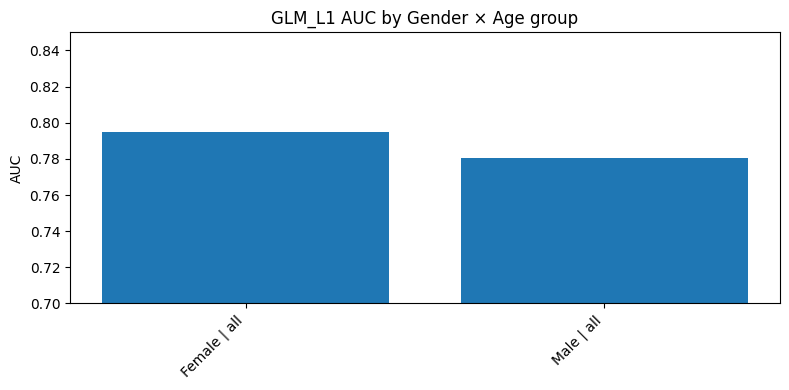

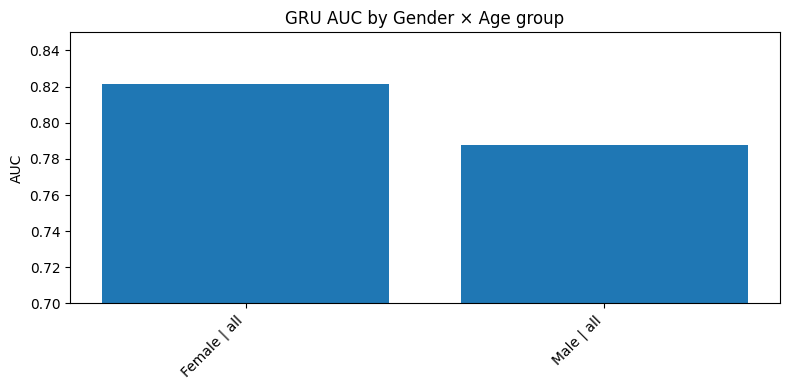

In [32]:
# =========================
# Subgroup AUC plots
# =========================

plot_df = row_summary.copy()
plot_df = plot_df[np.isfinite(plot_df['auc'])]

for model_name in plot_df['model'].unique():
    sub = plot_df[plot_df['model'] == model_name]
    plt.figure(figsize=(8, 4))
    plt.bar(sub['group'], sub['auc'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('AUC')
    plt.ylim([0.7,0.85])
    plt.title(f'{model_name} AUC by Gender × Age group')
    plt.tight_layout()
    plt.show()

In [29]:
# =========================
# Overall + subgroup row-level comparison table
# =========================

overall_row_results = []

if "glm_metrics" in globals() and glm_metrics is not None:
    overall_row_results.append({
        "model": "GLM_L1",
        "group": "Overall",
        "n_rows": len(y_test),
        "n_positive_rows": int(np.sum(y_test == 1)),
        "n_negative_rows": int(np.sum(y_test == 0)),
        "auc": glm_metrics["auc"],
        "accuracy_at_optimal_threshold": glm_metrics["accuracy_at_optimal_threshold"],
        "optimal_threshold": glm_metrics["optimal_threshold"],
        "sensitivity_at_optimal_threshold": glm_metrics["sensitivity_at_optimal_threshold"],
        "specificity_at_optimal_threshold": glm_metrics["specificity_at_optimal_threshold"],
    })

if "xgb_metrics" in globals() and xgb_metrics is not None:
    overall_row_results.append({
        "model": "XGBoost",
        "group": "Overall",
        "n_rows": len(y_test),
        "n_positive_rows": int(np.sum(y_test == 1)),
        "n_negative_rows": int(np.sum(y_test == 0)),
        "auc": xgb_metrics["auc"],
        "accuracy_at_optimal_threshold": xgb_metrics["accuracy_at_optimal_threshold"],
        "optimal_threshold": xgb_metrics["optimal_threshold"],
        "sensitivity_at_optimal_threshold": xgb_metrics["sensitivity_at_optimal_threshold"],
        "specificity_at_optimal_threshold": xgb_metrics["specificity_at_optimal_threshold"],
    })

if "rnn_metrics" in globals() and rnn_metrics is not None:
    overall_row_results.append({
        "model": "GRU",
        "group": "Overall",
        "n_rows": len(test_seq_y),
        "n_positive_rows": int(np.sum(test_seq_y == 1)),
        "n_negative_rows": int(np.sum(test_seq_y == 0)),
        "auc": rnn_metrics["auc"],
        "accuracy_at_optimal_threshold": rnn_metrics["accuracy_at_optimal_threshold"],
        "optimal_threshold": rnn_metrics["optimal_threshold"],
        "sensitivity_at_optimal_threshold": rnn_metrics["sensitivity_at_optimal_threshold"],
        "specificity_at_optimal_threshold": rnn_metrics["specificity_at_optimal_threshold"],
    })

overall_row_df = pd.DataFrame(overall_row_results)

# subgroup_row_df should already exist from your subgroup section
row_comparison_table = pd.concat(
    [overall_row_df, subgroup_row_df],
    ignore_index=True
)

row_comparison_table = row_comparison_table[[
    "model",
    "group",
    "n_rows",
    "n_positive_rows",
    "n_negative_rows",
    "auc",
    "accuracy_at_optimal_threshold",
    "optimal_threshold",
    "sensitivity_at_optimal_threshold",
    "specificity_at_optimal_threshold",
]].sort_values(["model", "group"]).reset_index(drop=True)

print("Overall + age/sex subgroup row-level performance:")
display(row_comparison_table)

# =========================
# Compact final results table
# =========================

final_results_table = row_comparison_table[[
    "model",
    "group",
    "n_rows",
    "n_positive_rows",
    "auc",
    "sensitivity_at_optimal_threshold",
    "specificity_at_optimal_threshold",
]].copy()

final_results_table = final_results_table.rename(columns={
    "n_rows": "N rows",
    "n_positive_rows": "Positive rows",
    "auc": "AUC",
    "sensitivity_at_optimal_threshold": "Sensitivity",
    "specificity_at_optimal_threshold": "Specificity",
})

print("Final overall vs. age/sex subgroup comparison table:")
display(final_results_table)

Overall + age/sex subgroup row-level performance:


,model,group,n_rows,n_positive_rows,n_negative_rows,auc,accuracy_at_optimal_threshold,optimal_threshold,sensitivity_at_optimal_threshold,specificity_at_optimal_threshold
0,GLM_L1,Female | all,185470,762,184708,0.794770,0.786726,0.482823,0.692913,0.787113
1,GLM_L1,Male | all,230438,992,229446,0.780383,0.729771,0.472420,0.697581,0.729910
2,GLM_L1,Overall,415908,1754,414154,0.787263,0.760625,0.480819,0.688712,0.760930
3,GRU,Female | all,150302,622,149680,0.821289,0.819111,0.016155,0.676849,0.819702
4,GRU,Male | all,186745,818,185927,0.787403,0.760465,0.005391,0.685819,0.760793
5,GRU,Overall,337047,1440,335607,0.801613,0.755114,0.005375,0.702083,0.755342


Final overall vs. age/sex subgroup comparison table:


,model,group,N rows,Positive rows,AUC,Sensitivity,Specificity
0,GLM_L1,Female | all,185470,762,0.794770,0.692913,0.787113
1,GLM_L1,Male | all,230438,992,0.780383,0.697581,0.729910
2,GLM_L1,Overall,415908,1754,0.787263,0.688712,0.760930
3,GRU,Female | all,150302,622,0.821289,0.676849,0.819702
4,GRU,Male | all,186745,818,0.787403,0.685819,0.760793
5,GRU,Overall,337047,1440,0.801613,0.702083,0.755342


In [30]:
# =========================
# Overall + subgroup patient-time comparison table
# =========================

overall_pt_results = []

if "glm_ewt" in globals() and glm_ewt is not None:
    overall_pt_results.append({
        "model": "GLM_L1",
        "group": "Overall",
        **glm_ewt
    })

if "xgb_ewt" in globals() and xgb_ewt is not None:
    overall_pt_results.append({
        "model": "XGBoost",
        "group": "Overall",
        **xgb_ewt
    })

if "rnn_ewt" in globals() and rnn_ewt is not None:
    overall_pt_results.append({
        "model": "GRU",
        "group": "Overall",
        **rnn_ewt
    })

overall_pt_df = pd.DataFrame(overall_pt_results)

patient_time_comparison_table = pd.concat(
    [overall_pt_df, subgroup_patient_time_df],
    ignore_index=True
)

patient_time_comparison_table = patient_time_comparison_table[[
    "model",
    "group",
    "n_positive_patients",
    "n_detected_positive_patients",
    "patient_sensitivity",
    "n_negative_patients",
    "false_alert_patient_rate",
    "median_early_warning_time_hours",
    "mean_early_warning_time_hours",
]].sort_values(["model", "group"]).reset_index(drop=True)

print("Overall + age/sex subgroup patient-time performance:")
display(patient_time_comparison_table)

Overall + age/sex subgroup patient-time performance:


,model,group,n_positive_patients,n_detected_positive_patients,patient_sensitivity,n_negative_patients,false_alert_patient_rate,median_early_warning_time_hours,mean_early_warning_time_hours
0,GLM_L1,Female | all,382,334,0.874346,5004,0.594125,41.5,59.314371
1,GLM_L1,Male | all,498,438,0.879518,6217,0.680875,29.0,50.636986
2,GLM_L1,Overall,880,772,0.877273,11221,0.642189,34.0,54.391192
3,GRU,Female | all,382,328,0.858639,5004,0.824940,38.0,58.472561
4,GRU,Male | all,498,426,0.855422,6217,0.816793,30.0,49.802817
5,GRU,Overall,880,754,0.856818,11221,0.820426,33.0,53.574271


## Save outputs

In [13]:
# =========================
# Save outputs
# =========================

with open(OUTPUT_DIR / 'metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

with open(OUTPUT_DIR / 'patient_split.json', 'w') as f:
    json.dump({'train_patient_ids': train_ids, 'test_patient_ids': test_ids}, f, indent=2)

gender_counts_patients.to_csv(OUTPUT_DIR / 'gender_distribution_patients.csv', index=False)
age_summary_by_gender.to_csv(OUTPUT_DIR / 'age_summary_by_gender.csv', index=False)
test_demo_summary.to_csv(OUTPUT_DIR / 'test_demographic_groups.csv', index=False)
subgroup_row_df.to_csv(OUTPUT_DIR / 'subgroup_row_level_metrics.csv', index=False)
subgroup_patient_time_df.to_csv(OUTPUT_DIR / 'subgroup_patient_time_metrics.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR.resolve())

Saved outputs to: /Users/roseva1/Desktop/home/rose1838/SP26/PUBH8475/PUBH8475/Final/results_notebook
